In [2]:
def region_id(region_name):
    mapping={
       "Tunis":1,
       "Sousse": 2,
        "Kairouan": 3
    }
    return mapping.get(region_name, None)
def region_id(region_name):
    mapping={
        "Sousse": 1,
        "Tunis": 2,
        "Kairouan": 3
    }
    return mapping.get(region_name, None)
def eudcation_level_id(level_name):
    mapping={
        "Primary": 1,
        "Middle School": 2,
        "High School": 3,
        "Higher Education": 4
    }
    return mapping.get(level_name, None)
def program_id(program_name):
    mapping={
        "Academic Catch-up": 1,
        "Vocational Training": 2,
        "Second Chance School": 3,
        "Community Integration": 4
    }
    return mapping.get(program_name, None)
def reason_id(reason_name):
    mapping={
        "Financial": 1,
        "Academic": 2,
        "Family": 3,
        "Health": 4,
        "Distance": 5,
        "Work": 6,
        "Marriage": 7
    }
    return mapping.get(reason_name, None)


In [ ]:
import datetime
from dateutil import parser as date_parser
def normalize_education_level(level):
    if not level:
        return None
    level_lower = level.strip().lower()
    education_mapping = {
        'primaire': 'Primary', 'primary': 'Primary', 'ابتدائي': 'Primary',
        'collège': 'Middle School', 'college': 'Middle School', 'إعدادي': 'Middle School',
        'lycée': 'High School', 'lycee': 'High School', 'ثانوي': 'High School',
        'supérieur': 'Higher Education', 'superieur': 'Higher Education', 'العالي': 'Higher Education'
    }
    return education_mapping.get(level_lower, 'Primary')
def normalize_gender(gender):
    if not gender:
        return 'M'
    gender_lower = gender.strip().lower()
    
    gender_mapping = {
    'm': 'M', 'masculin': 'M', 'male': 'M', 'ذكر': 'M',
    'f': 'F', 'féminin': 'F', 'feminin': 'F', 'female': 'F', 'أنثى': 'F'
    }
    return gender_mapping.get(gender_lower, 'M')
def normalize_boolean(value):
    if not value:
        return False
    value_lower = value.strip().lower()
    bool_mapping = {
    'oui': True, 'yes': True, 'true': True, '1': True, 't': True, 'y': True,
    'non': False, 'no': False, 'false': False, '0': False, 'f': False, 'n': False
    }

    return bool_mapping.get(value_lower, False)
def normalize_reason(reason):
    if not reason:
        return 'Family'
    reason_lower = reason.strip().lower()
    reason_mapping = {
    'financial': 'Financial', 'financier': 'Financial', 'مالي': 'Financial', 'FIN': 'Financial',
    'difficultés financières': 'Financial', 'صعوبات مالية': 'Financial', 'نقص الأموال': 'Financial',
    'academic': 'Academic', 'académique': 'Academic', 'أكاديمي': 'Academic',
    'poor performance': 'Academic', 'mauvaise performance': 'Academic', 'ضعف الأداء': 'Academic',
    'échec scolaire': 'Academic', 'فشل دراسي': 'Academic',
    'personal': 'Family', 'personnel': 'Family', 'شخصي': 'Family',
    'family issues': 'Family', 'problèmes familiaux': 'Family', 'مشاكل عائلية': 'Family',
    'health': 'Health', 'santé': 'Health', 'صحة': 'Health',
    'medical issues': 'Health', 'problèmes médicaux': 'Health', 'مشاكل طبية': 'Health',
    'problèmes de santé': 'Health', 'مشاكل صحية': 'Health',
    'distance': 'Distance', "distance de l'école": 'Distance', 'بعد المدرسة': 'Distance',
    'work': 'Work', 'emploi': 'Work', 'عمل': 'Work', 'job commitments': 'Work',
    'engagements professionnels': 'Work', 'الالتزامات الوظيفية': 'Work', 'هجرة للعمل': 'Work',
    'migration pour travail': 'Work',
    'marriage': 'Marriage', 'mariage': 'Marriage', 'زواج': 'Marriage',
    'early marriage': 'Marriage', 'mariage précoce': 'Marriage', 'زواج مبكر': 'Marriage'
    }

    return reason_mapping.get(reason_lower, 'Family')
def clean_date(date_str):
    if not date_str or date_str in ['NULL', 'NA', '']:
        return None
    
    try:
        parsed_date = date_parser.parse(date_str, dayfirst=True)
        return parsed_date.date()
    except:
        return None
def calculate_age(birth_date):
    today = datetime.date.today()
    age = today.year - birth_date.year  - ((today.month, today.day) < (birth_date.month, birth_date.day))
    return age
def calculate_days_between(start_date, end_date):
    if not start_date or not end_date:
        return None
    days_calculated = end_date - start_date
    return days_calculated.days
def normalize_program(program):
    if not program:
        return 'Second Chance School'
    program_lower = program.strip().lower()
    program_mapping = {
    'programme espoir': 'Academic Catch-up',
    'espoir': 'Academic Catch-up',
    'hope program': 'Academic Catch-up',
    'برنامج الأمل': 'Academic Catch-up',
    'formation professionnelle': 'Vocational Training',
    'formation professionnelle rapide': 'Vocational Training',
    'rapid vocational training': 'Vocational Training',
    'التكوين المهني': 'Vocational Training',
    'chance seconde': 'Second Chance School',
    'second chance': 'Second Chance School',
    'فرصة ثانية': 'Second Chance School',
    'insertion communautaire': 'Community Integration',
    'community integration': 'Community Integration',
    'community': 'Community Integration',
    'الإدماج المجتمعي': 'Community Integration'
}
    return program_mapping.get(program_lower, 'Second Chance School')


In [ ]:

def transform_tunisia_dropout_data(row):
   
    date_birth =  row.get('date_of_birth', None) 
    gender= normalize_gender(row['gender'])
    delegation= row['delegation']
    delegation_str= str(delegation).strip().title() 
    education_level= normalize_education_level(row['education_level'])
 
    reintegration_str= str(row.get('reintegration_success','0'))
    reintegration_success= normalize_boolean(reintegration_str)
    program_name=normalize_program(row['program_name'])
    reason_name= normalize_reason(row.get('reason_code',''))
    reintegration_start= row.get('reintegration_start','')
    
    dropout_date= clean_date(row['dropout_date'])
    if date_birth:
        age= calculate_age(date_birth)
    else:
        age=0
    if reintegration_success:
        reintegration_date= clean_date(reintegration_start)
    else:
        reintegration_date= None
    if reintegration_date and dropout_date:
        days_to_reintegrate= calculate_days_between(dropout_date, reintegration_date)
    else:
        days_to_reintegrate= 0
    transformed_row= {
        'student_id': row['student_id'],
        'gender': gender,
        'age': age,
        'delegation': delegation_str,
        'level_name': education_level,
        'program_name': program_name,
        'reason_name': reason_name,
        'region_name':'Tunis',
        'dropout_date': dropout_date,
        'reintegration_date': reintegration_date,
        'days_to_reintegrate': days_to_reintegrate,
        'reintegrated': reintegration_success,
    }
    return transformed_row




In [8]:
import psycopg2
import pandas as pd
import pygrametl
import datetime as datetime
from pygrametl.datasources import CSVSource, SQLSource
from pygrametl.tables import Dimension, FactTable, SlowlyChangingDimension
import mysql.connector
from dateutil import parser 
CSVFile="cleaned_sousse_dropout.csv"

# connected to PostgreSQL
try:
    pgconn=psycopg2.connect("dbname=education_dropout_dwh user=postgres password=0000 ")
    connection=pygrametl.ConnectionWrapper(pgconn)
    connection.setasdefault()
    print("Connection successful")
except Exception as e:
    print("Connection failed")
    print(e)  
#creating the control table 
def create_control_table(conn):
    cursor = conn.cursor()
    cursor.execute("""
        create table if not exists etl_control (
            control_id SERIAL PRIMARY KEY,
            source_name VARCHAR(50) UNIQUE,
            last_success_date TIMESTAMP,
            records_processed INTEGER,
            status VARCHAR(20)
        );
    """)
    conn.commit()
    print("Control table ready")   
def get_last_success_date(conn, source_name):
    cursor = conn.cursor()
    cursor.execute(f"SELECT last_success_date FROM etl_control WHERE source_name=%s AND status='SUCCESS'",(source_name,))
    result = cursor.fetchone()
    if result:
          return result[0]
    else:
          return None
def update_control_table(conn, source_name, records, status):
    cursor = conn.cursor()
    cursor.execute(""" insert into etl_control (source_name, last_success_date, records_processed, status)
        values (%s, %s, %s, %s)
        on conflict (source_name) do update set
            last_success_date = EXCLUDED.last_success_date,
            records_processed = EXCLUDED.records_processed,
            status = EXCLUDED.status;
    """, (source_name, datetime.datetime.now() if status=='SUCCESS' else None, records, status))
    conn.commit()
create_control_table(pgconn)
'''Defining the dimensions and fact tables '''
dim_student = SlowlyChangingDimension(
    name='dim_student',
    key='student_id',
  attributes=[ 'code_student', 'gender', 'age', 'delegation',
            'version', 'valid_from', 'valid_to'],  # Add 'source'
    lookupatts=[ 'code_student'],  
    versionatt='version',          
    fromatt='valid_from',          
    toatt='valid_to',               
    srcdateatt='effective_date',   
    type1atts=['gender' ],  # These update WITHOUT new version
              
)
dim_education_level= Dimension(
    name='dim_education_level',
    key='level_id',
    attributes=['level_name'],
    lookupatts=['level_name']
)
dim_program= Dimension(
    name='dim_program',
    key='program_id',
    attributes=['program_name', 'program_type','duration_months'],
    lookupatts=['program_name']


)
dim_dropout_reason= Dimension(
    name='dim_dropout_reason',
    key='reason_id',
    attributes=['reason_name', 'category'],
    lookupatts=['reason_name']
)
dim_region= Dimension(
    name='dim_region',
    key='region_id',
    attributes=['region_name', 'country'],
    lookupatts=['region_name']
)
dim_time = Dimension(
    name='dim_time',
    key='time_id',
    attributes=['date','month','year','day'],
    lookupatts=['date']
)
fact_education_dropout= FactTable(
    name='fact_education_dropout',
    keyrefs=['student_id','education_level_id','program_id','reason_id','region_id','dropout_date_id','reintegration_date_id'],
    measures=['reintegrated', 'days_to_reintegration', 'dropout_count']
    
)
#fill the dimension time with dates from 2021-01-01 to 2025-12-31
start_date= datetime.date(2021,1,1)
end_date= datetime.date(2025,12,31)
current_date= start_date
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')
for single_date in all_dates:
    time_row= {
        'date': single_date.date(),
        'month': single_date.month,
        'year': single_date.year,
        'day': single_date.day
    }
    dim_time.ensure(time_row)
'''filling the static dimension data'''
#fii the region dimension with predefined regions
regions= [
    {'region_id':1, 'region_name':'Tunis', 'country':'Tunisia'},
    {'region_id':2, 'region_name':'Sousse', 'country':'Tunisia'},
    {'region_id':3, 'region_name':'Kairouan', 'country':'Tunisia'}]
for region in regions:
    dim_region.ensure(region)
#load data to education level dimension
education_levels= [
    {'level_id':1, 'level_name':'Primary'},
    {'level_id':2, 'level_name':'Middle School'},
    {'level_id':3, 'level_name':'High School'},
    {'level_id':4, 'level_name':'Higher Education'}]
for level in education_levels:
    dim_education_level.ensure(level)
#load data to program dimension
programs= [
    {'program_id':1, 'program_name':'Second Chance School', 'program_type':'Mixed', 'duration_months':18},
    {'program_id':2, 'program_name':'Academic Catch-up', 'program_type':'Academic', 'duration_months':12},
    {'program_id':3, 'program_name':'Vocational Training', 'program_type':'Vocational', 'duration_months':6},
    {'program_id':4, 'program_name':'Community Integration', 'program_type':'Social', 'duration_months':9}
    ]
for program in programs:
    dim_program.ensure(program)
#load data to dropout reason dimension
dropout_reasons= [
    {'reason_id':1, 'reason_name':'Financial', 'category':'Financial hardship '},
    {'reason_id':2, 'reason_name':'Family', 'category':'Family issues'},
    {'reason_id':3, 'reason_name':'Health', 'category':'Health problems'},
    {'reason_id':4, 'reason_name':'Academic', 'category':'Academic failure or difficulties'},
    {'reason_id':5, 'reason_name':'Marriage', 'category':'Early marriage'},
    {'reason_id':6, 'reason_name':'Work', 'category':'Employment migration'},
    {'reason_id':7, 'reason_name':'Distance', 'category':'Transportation issues'}
]
for reason in dropout_reasons:
    dim_dropout_reason.ensure(reason)
# Process ETL in CSV file (Sousse data)
last_sousse_date = get_last_success_date(pgconn, 'SOUSSE_CSV')
file= open(CSVFile, 'r',16384)
csvsource= CSVSource(file, delimiter=',')
sousse_count = 0
seen_students = set()
for row in csvsource:
    dropout_date_str = row.get('date_abandon', '').strip()
    dropout_date= clean_date(dropout_date_str)
    if last_sousse_date:
        last_sousse_date = clean_date(last_sousse_date) 
    if  last_sousse_date and dropout_date <= last_sousse_date:
        continue  
    student_row= {
            'gender': row['sexe'],
            'age': int(float(row['age'])),
            'delegation': row['delegation'],
            'code_student':str( row['etudiant_id']),
            'effective_date': dropout_date
        }
  
    student_id= dim_student.scdensure(student_row)
    print(f"Processed student ID: {student_id}")
   
    dropout_date_row= {
                'date': dropout_date,
                'month': dropout_date.month,
                'year': dropout_date.year,
                'day': dropout_date.day
            }
    dropout_date_id= dim_time.ensure(dropout_date_row)
    reintegration_date_str = row.get('date_reintegration', '').strip()
    reintegration_date= clean_date(reintegration_date_str)
    if reintegration_date:
                reintegration_date_row= {
                    'date': reintegration_date,
                    'month': reintegration_date.month,
                    'year': reintegration_date.year,
                    'day': reintegration_date.day
                }
                reintegration_date_id= dim_time.ensure(reintegration_date_row)
                days_str = row.get('days_to_reintegration', '').strip()
                if days_str and days_str != '':
                    days_to_reintegration = int(float(days_str))
                else: 
                    days_to_reintegration = calculate_days_between(dropout_date, reintegration_date)
            
    else:
                reintegration_date_id= None
                days_to_reintegration= 0
    reintegrated= row.get('reintegre').strip()

            
    level_id= dim_education_level.lookup({'level_name': row['niveau_education']})
    program_id=dim_program.lookup({'program_name': row['programme']})
    reason_id= dim_dropout_reason.lookup({'reason_name': row['motif_abandon']})
    region_id= dim_region.lookup({'region_name': row['region']})
    if  student_id in seen_students:
              dropout_count += 1  
    else:
              dropout_count = 1
              seen_students.add(student_id)

    fact_row= {
                'student_id': student_id,
                'education_level_id': level_id,
                'program_id': program_id,
                'reason_id': reason_id,
                'region_id': region_id,
                'dropout_date_id': dropout_date_id,
                'reintegration_date_id': reintegration_date_id,
                'reintegrated': reintegrated,
                'days_to_reintegration': days_to_reintegration,
                'dropout_count': dropout_count
            }
    fact_education_dropout.insert(fact_row)
    sousse_count += 1
file.close()
update_control_table(pgconn, 'SOUSSE_CSV', sousse_count, 'SUCCESS')
print(f"Sousse: {sousse_count}")

#Tunis Database extraction

connection_tunis = mysql.connector.connect(host='localhost', database='tunis_education_system', user='root', password='')
mysql_wrapper= pygrametl.ConnectionWrapper(connection_tunis)
last_tunis_date = get_last_success_date(pgconn, 'TUNIS_DB')
query = f"""
Select s.student_id, s.date_of_birth, s.gender, s.delegation, s.education_level,
d.dropout_date, d.reason_code,d.reason_description,
r.program_name,r.start_date AS reintegration_start,r.completion_date AS reintegration_completion,r.success AS reintegration_success
from students s
INNER JOIN dropout_records d ON s.student_id = d.student_id
LEFT JOIN reintegration_tracking r ON d.dropout_id = r.dropout_id
where d.dropout_date > '{last_tunis_date}'
ORDER BY d.dropout_date
"""
tunis_source = SQLSource(mysql_wrapper, query)
tunis_count = 0
for row in tunis_source:
        dropout_count= 0
        dropout_date_str= str(row.get('dropout_date','')).strip()
        dropout_date= clean_date(dropout_date_str)
        transformed_row= transform_tunisia_dropout_data(row)
        student_row= {
            'gender': transformed_row['gender'],
            'code_student':str( row['student_id']),
            'age': transformed_row['age'],
            'delegation': transformed_row['delegation'],
            'effective_date': dropout_date
        }
        student_id= dim_student.scdensure(student_row)
        

        print(f"Processed student ID: {student_id}")
        print("age", transformed_row['age'])
       

        dropout_date_row= {
                'date': dropout_date,
                'month': dropout_date.month,
                'year': dropout_date.year,
                'day': dropout_date.day
            }
        dropout_date_id= dim_time.ensure(dropout_date_row)
        reintegration_date_str= str(row.get('reintegration_completion','')).strip()
        reintegration_date= clean_date(reintegration_date_str)
        if reintegration_date:
                reintegration_date_row= {
                    'date': reintegration_date,
                    'month': reintegration_date.month,
                    'year': reintegration_date.year,
                    'day': reintegration_date.day
                }
                reintegration_date_id= dim_time.ensure(reintegration_date_row)
                days_to_reintegrate= calculate_days_between(dropout_date, reintegration_date)
               
        else:
                reintegration_date_id= None
                days_to_reintegrate = 0
        level_id= dim_education_level.lookup({'level_name': transformed_row['level_name']})
        program_id=dim_program.lookup({'program_name': transformed_row['program_name']})
        reason_id= dim_dropout_reason.lookup({'reason_name': transformed_row['reason_name']})
        region_id= dim_region.lookup({'region_name': transformed_row['region_name']})   
        # if student id repeated increment dropout count
        if  student_id in seen_students:
              dropout_count += 1  
        else:
              dropout_count = 1
              seen_students.add(student_id)
       
        fact_row= {
                'student_id': student_id,
                'education_level_id': level_id,
                'program_id': program_id,
                'reason_id': reason_id,
                'region_id': region_id,
                'dropout_date_id': dropout_date_id,
                'reintegration_date_id': reintegration_date_id,
                'reintegrated': transformed_row['reintegrated'],
                'days_to_reintegration': days_to_reintegrate,
                'dropout_count': dropout_count
            }
      
        fact_education_dropout.insert(fact_row)
        tunis_count += 1
connection_tunis.close()
print(f"Tunis: {tunis_count}")
update_control_table(pgconn, 'TUNIS_DB', tunis_count, 'SUCCESS')
print("Connection to Tunis DB successful")
connection.commit()
connection.close()        

# Summary 

print("ETL process done")
print(f"""
Data Sources:
Total Fact Records: {sousse_count + tunis_count}
Dimensions Loaded:
Time: {len(all_dates)} dates
Regions: {len(regions)}
Education Levels: {len(education_levels)}
Programs: {len(programs)}
Dropout Reasons: {len(dropout_reasons)}""")

       

    
    

Connection successful
Control table ready
Processed student ID: 1
Processed student ID: 2
Processed student ID: 3
Processed student ID: 4
Processed student ID: 5
Processed student ID: 6
Processed student ID: 7
Processed student ID: 8
Processed student ID: 9
Processed student ID: 10
Processed student ID: 11
Processed student ID: 12
Processed student ID: 13
Processed student ID: 14
Processed student ID: 15
Processed student ID: 16
Processed student ID: 17
Processed student ID: 18
Processed student ID: 19
Processed student ID: 20
Processed student ID: 21
Processed student ID: 22
Processed student ID: 23
Processed student ID: 24
Processed student ID: 25
Processed student ID: 26
Processed student ID: 27
Processed student ID: 28
Processed student ID: 29
Processed student ID: 30
Processed student ID: 31
Processed student ID: 32
Processed student ID: 33
Processed student ID: 34
Processed student ID: 35
Processed student ID: 36
Processed student ID: 37
Processed student ID: 38
Processed student

Connection successful


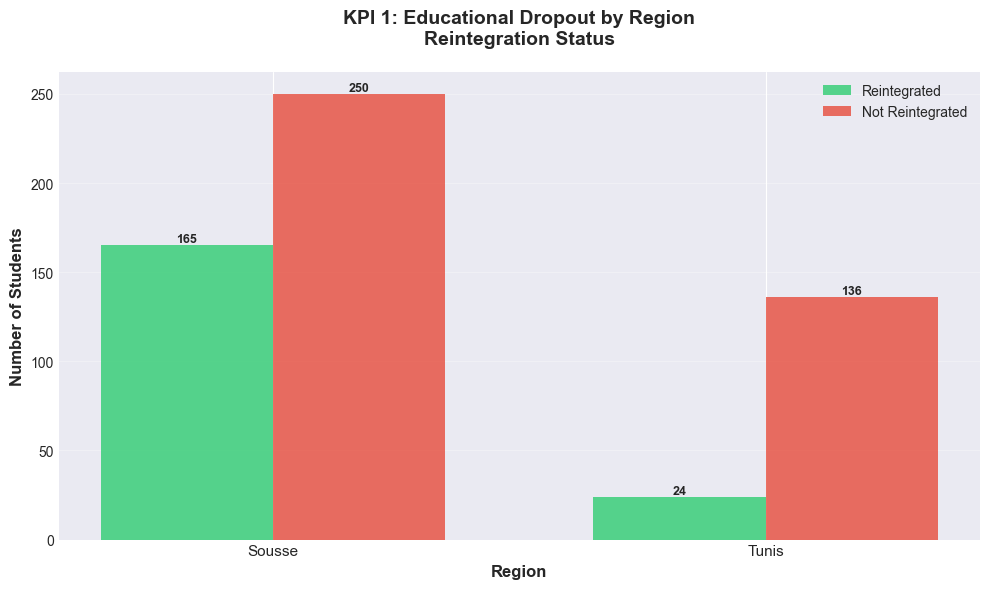

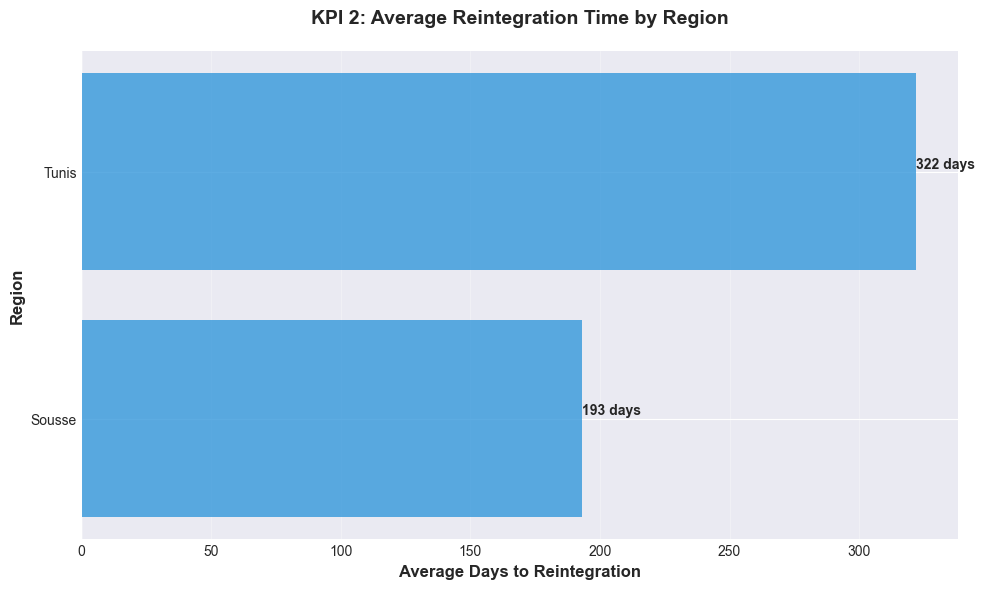

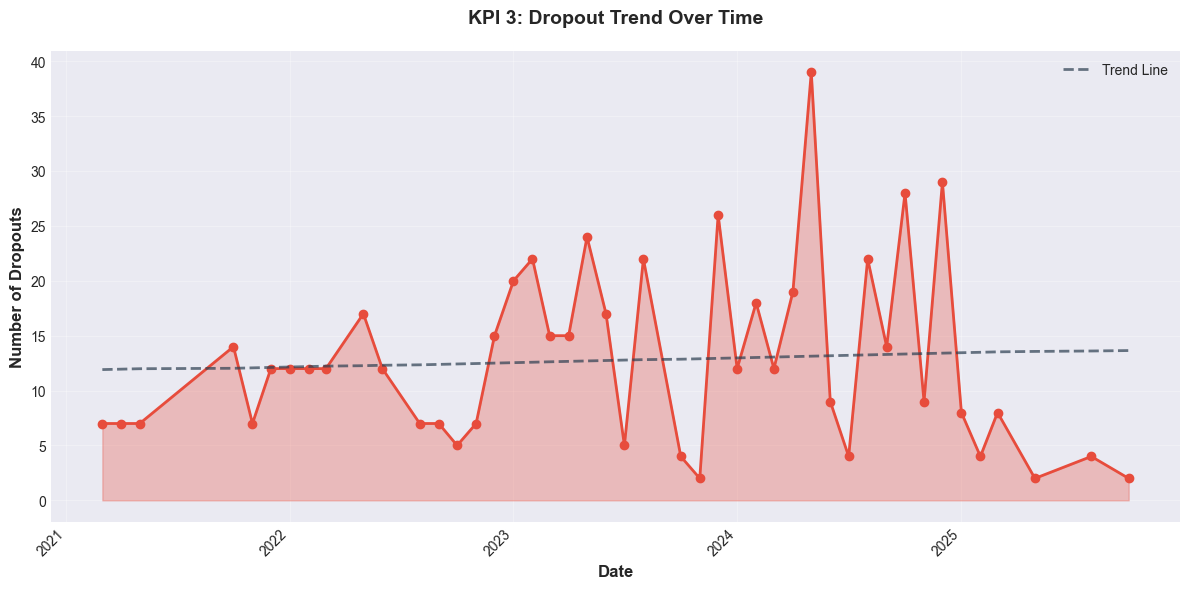

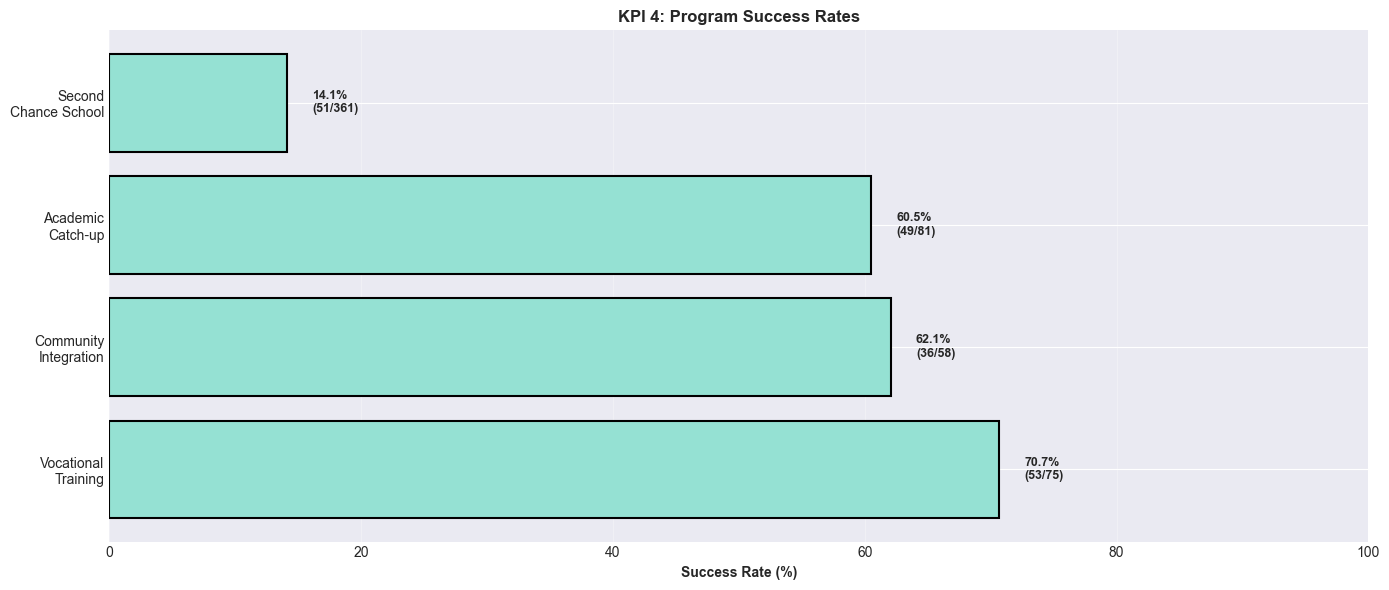

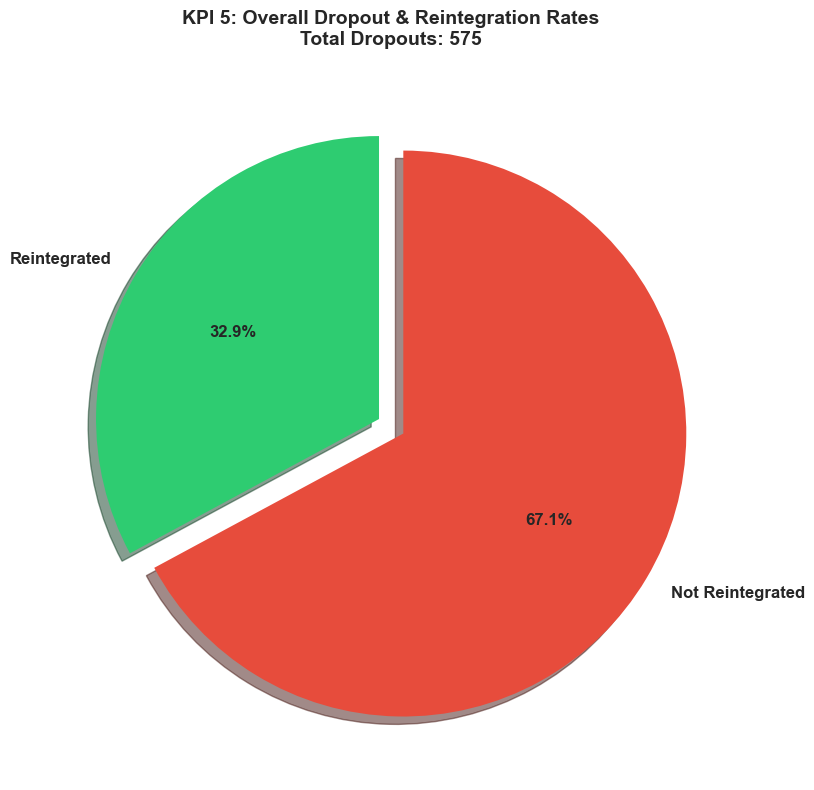

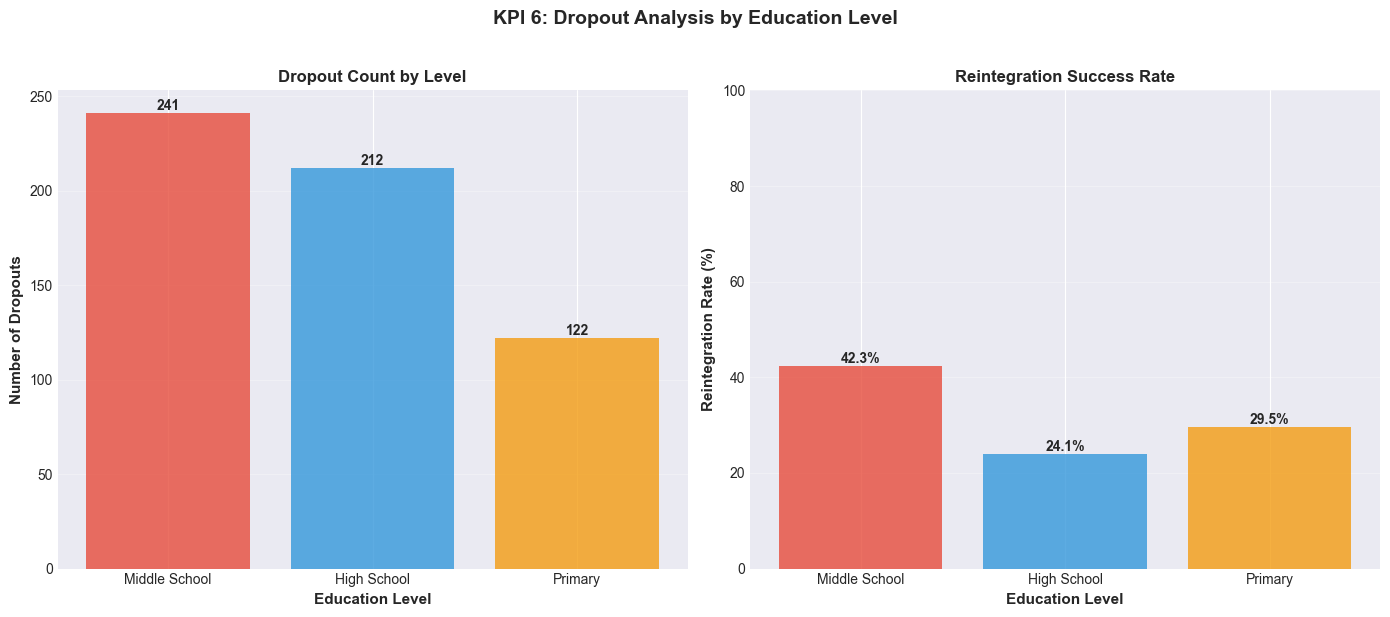

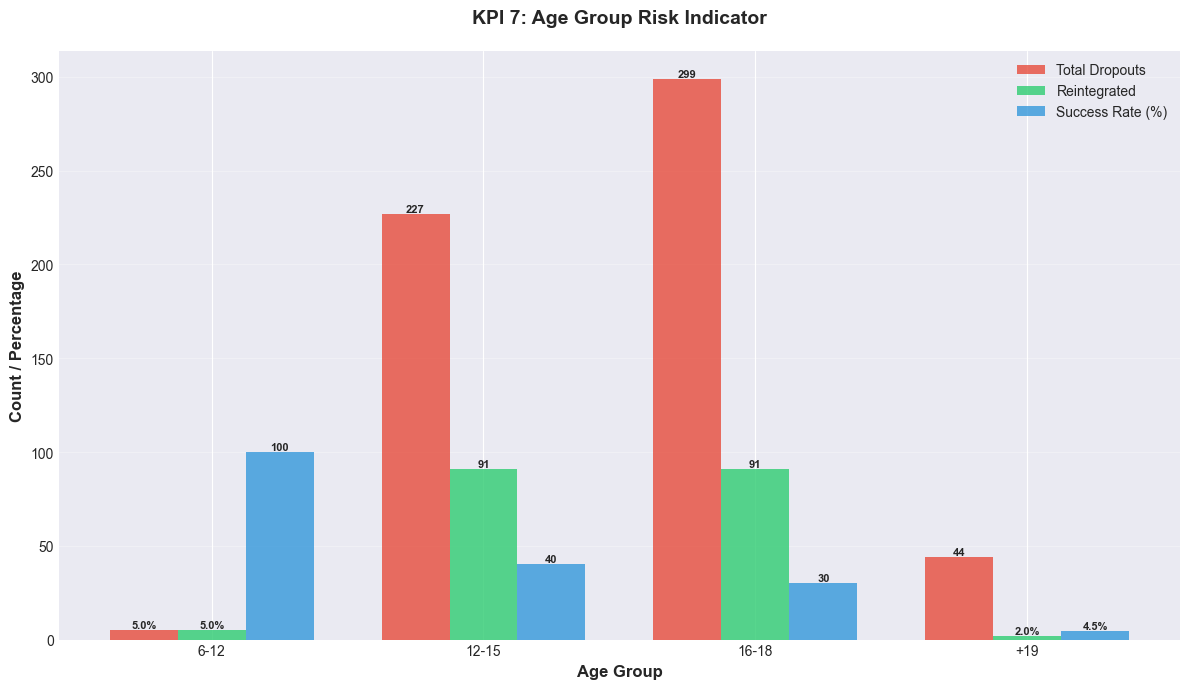

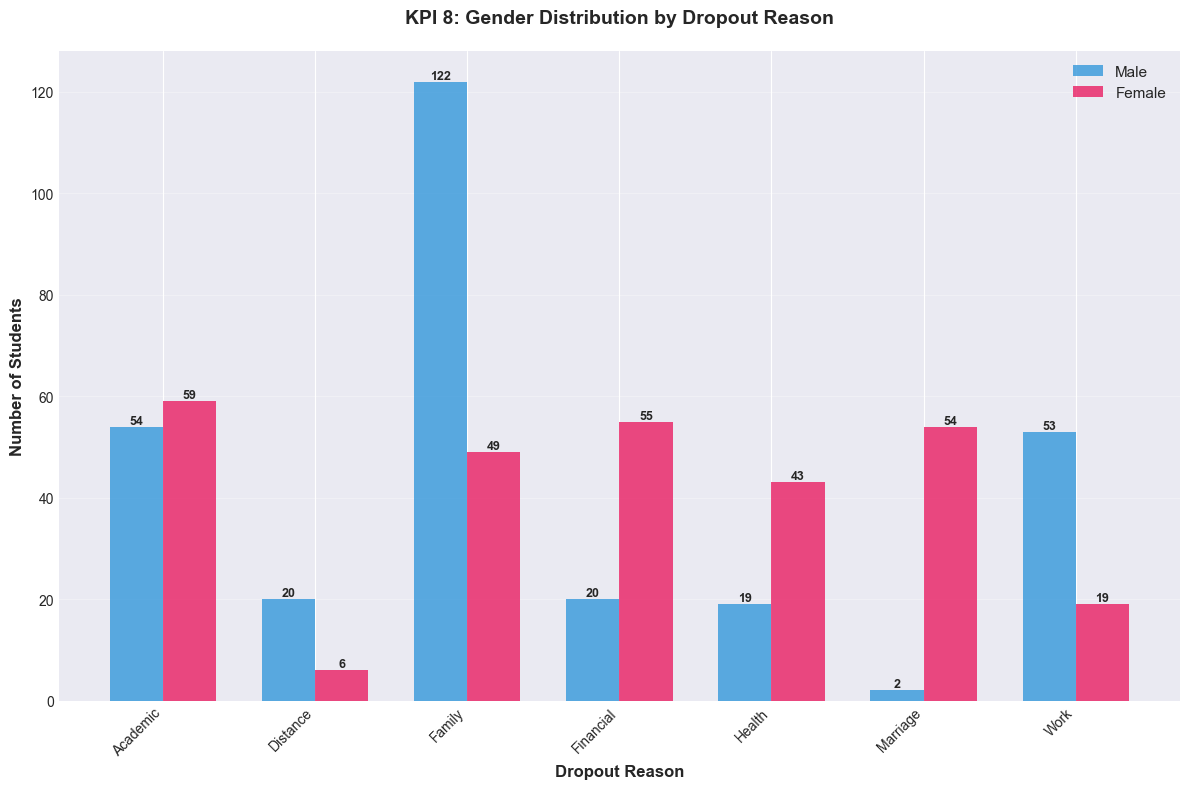

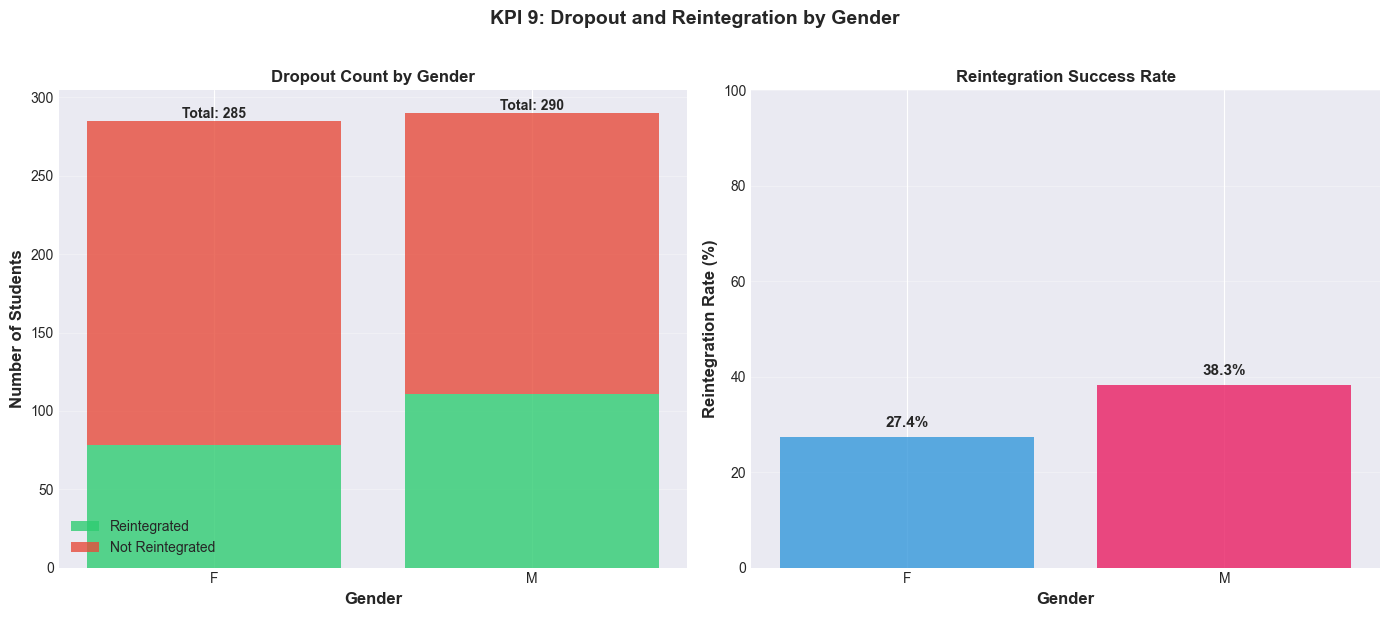

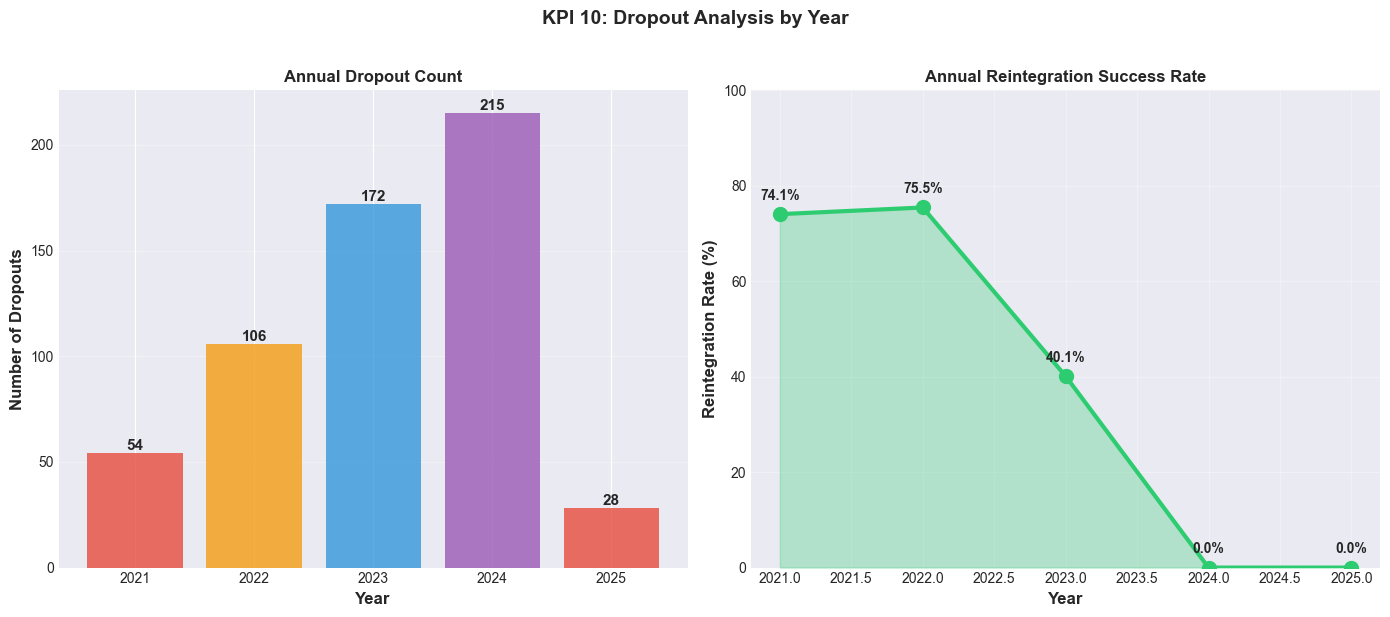

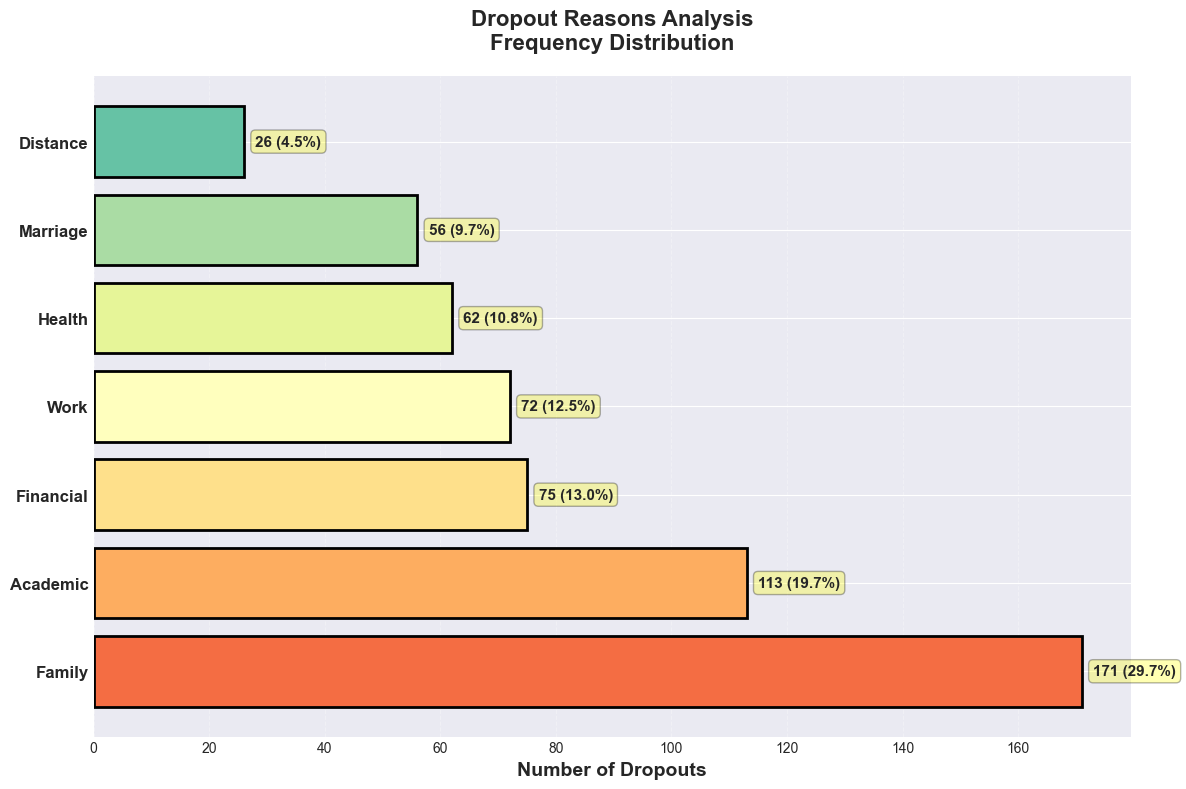

In [9]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
"""KPI's Plot"""
#Set the style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# i connected to my database 
try:
    pgconn=psycopg2.connect("dbname=education_dropout_dwh user=postgres password=0000 ")
    cursor = pgconn.cursor()
    print("Connection successful")
except Exception as e:
    print("Connection failed")
    print(e)
'''KPI 1 : Educational Dropout by Region'''
query_region="""select r.region_name , COUNT(*) as total_dropouts ,
 SUM(case when f.reintegrated then 1 else 0 end) as reintegrated,
 COUNT(*) - SUM(case when f.reintegrated then 1 else 0 end) as not_reintegrated
 FROM fact_education_dropout f
 JOIN dim_region r ON f.region_id = r.region_id
 GROUP BY r.region_name
 ORDER BY total_dropouts DESC;
"""
cursor.execute(query_region)
rows = cursor.fetchall()
regions = [row[0] for row in rows]
reintegrated = [row[2] for row in rows]
not_reintegrated = [row[3] for row in rows]
# Plot bar chart
fig1, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(regions))
width = 0.35
bars1 = ax1.bar(x - width/2, reintegrated, width, label='Reintegrated', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x + width/2, not_reintegrated, width, label='Not Reintegrated', color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Region', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Students', fontsize=12, fontweight='bold')
ax1.set_title('KPI 1: Educational Dropout by Region\nReintegration Status', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(regions, fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_1_region_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 2: Average Reintegration Time '''
query_time = """select r.region_name,ROUND(AVG(f.days_to_reintegration)) as avg_days,
COUNT(*) as reintegrated_count
from fact_education_dropout f
join dim_region r ON f.region_id = r.region_id
where f.reintegrated = TRUE AND f.days_to_reintegration IS NOT NULL
GROUP BY r.region_name
ORDER BY avg_days;
"""
cursor.execute(query_time)
rows = cursor.fetchall()
regions = [row[0] for row in rows]
avg_days = [row[1] for row in rows]
reintegration_counts = [row[2] for row in rows]

# Horizontal bar chart
fig2, ax2 = plt.subplots(figsize=(10, 6))
bars = ax2.barh(regions, avg_days, color='#3498db', alpha=0.8)
ax2.set_xlabel('Average Days to Reintegration', fontsize=12, fontweight='bold')
ax2.set_ylabel('Region', fontsize=12, fontweight='bold')
ax2.set_title('KPI 2: Average Reintegration Time by Region', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2., f'{int(width)} days\n', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_2_reintegration_time.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 3 : Dropout Trend Over Time'''
query_time_trend = """select  t.year,t.month,COUNT(*) as dropout_count
from fact_education_dropout f
join dim_time t ON f.dropout_date_id = t.time_id
GROUP BY t.year, t.month
ORDER BY t.year, t.month;
"""
cursor.execute(query_time_trend)
rows = cursor.fetchall()
dates = [f"{row[0]}-{row[1]:02d}-01" for row in rows]
dropouts = [row[2] for row in rows]
dates = [np.datetime64(date) for date in dates]
fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.plot(dates, dropouts, marker='o', linewidth=2, markersize=6, color='#e74c3c')
ax3.fill_between(dates, dropouts, alpha=0.3, color='#e74c3c')
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Dropouts', fontsize=12, fontweight='bold')
ax3.set_title('KPI 3: Dropout Trend Over Time', fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3)
z = np.polyfit(range(len(dropouts)), dropouts, 1)
p = np.poly1d(z)
ax3.plot(dates, p(range(len(dropouts))), "--", color='#2c3e50', linewidth=2, label='Trend Line', alpha=0.7)
ax3.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('kpi_3_dropout_trend.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 4 : Reintegration Program Effectivenes'''
query_program= """select  p.program_name, COUNT(*) as total_enrolled,  SUM(CASE WHEN f.reintegrated THEN 1 ELSE 0 END) as successful,
 ROUND(AVG(case when f.reintegrated then 1.0 else 0.0 end) * 100, 2) as success_rate
FROM fact_education_dropout f
JOIN dim_program p ON f.program_id = p.program_id
GROUP BY p.program_name
ORDER BY success_rate DESC;  """
cursor.execute(query_program)
rows = cursor.fetchall()
#Extract all the data to lists
programs = [row[0] for row in rows]
total_enrolled = [row[1] for row in rows]
successful = [row[2] for row in rows]
success_rate = [row[3] for row in rows]

fig4, ax4 = plt.subplots(1, 1, figsize=(14, 6))
program_names = [name.replace(' ', '\n', 1) for name in programs]
bars = ax4.barh(program_names, success_rate, color='#95E1D3', edgecolor='black', linewidth=1.5)
ax4.set_title('KPI 4: Program Success Rates', fontweight='bold', fontsize=12)
ax4.set_xlabel('Success Rate (%)', fontweight='bold')
ax4.set_xlim(0, 100)
ax4.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax4.text(width + 2, bar.get_y() + bar.get_height()/2.,
             f'{success_rate[i]:.1f}%\n({successful[i]}/{total_enrolled[i]})',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_4_program_success_rates.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
''' KPI 5: Dropout Rate (%) and Reintegration Rate (%)'''
query_rate=""" select COUNT(*) as total_dropouts,  SUM(CASE WHEN reintegrated THEN 1 ELSE 0 END) as reintegrated 
from fact_education_dropout;"""
cursor.execute(query_rate)
row = cursor.fetchone()
total_dropouts = row[0]
reintegrated_total = row[1]
not_reintegrated_total = total_dropouts - reintegrated_total
fig5, ax5 = plt.subplots(figsize=(10, 8))
sizes = [reintegrated_total, not_reintegrated_total]
labels = ['Reintegrated', 'Not Reintegrated']
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax5.pie(
    sizes, explode=explode, labels=labels,
    colors=colors, autopct='%1.1f%%', shadow=True, startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
ax5.set_title(f'KPI 5: Overall Dropout & Reintegration Rates\nTotal Dropouts: {total_dropouts}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('kpi_5_overall_rates.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 6: Dropout by Education Level'''
query_level="""select  e.level_name,  COUNT(*) as dropout_count,  SUM(CASE WHEN f.reintegrated THEN 1 ELSE 0 END) as reintegrated,
ROUND(AVG(CASE WHEN f.reintegrated THEN 1.0 ELSE 0.0 END) * 100, 2) as reintegration_rate
from fact_education_dropout f
join  dim_education_level e ON f.education_level_id= e.level_id
group by  e.level_name 
ORDER BY dropout_count DESC; """
cursor.execute(query_level)
rows = cursor.fetchall()
levels = [row[0] for row in rows]
dropout_counts = [row[1] for row in rows]
reintegration_counts = [row[2] for row in rows]
reintegration_rates = [row[3] for row in rows]

fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(14,6))
# Left: Dropout counts
colors_level = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
bars1 = ax6a.bar(levels, dropout_counts, color=colors_level[:len(levels)], alpha=0.8)
ax6a.set_xlabel('Education Level', fontsize=11, fontweight='bold')
ax6a.set_ylabel('Number of Dropouts', fontsize=11, fontweight='bold')
ax6a.set_title('Dropout Count by Level', fontsize=12, fontweight='bold')
ax6a.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax6a.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
# Right: Reintegration rates
bars2 = ax6b.bar(levels, reintegration_rates, color=colors_level[:len(levels)], alpha=0.8)
ax6b.set_xlabel('Education Level', fontsize=11, fontweight='bold')
ax6b.set_ylabel('Reintegration Rate (%)', fontsize=11, fontweight='bold')
ax6b.set_title('Reintegration Success Rate', fontsize=12, fontweight='bold')
ax6b.set_ylim(0, 100)
ax6b.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars2, reintegration_rates):
    ax6b.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
fig6.suptitle('KPI 6: Dropout Analysis by Education Level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kpi_6_education_level.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 7: Age Group Risk Indicator'''
query_age = """
select age_group, COUNT(*) as dropout_count, SUM(CASE WHEN reintegrated THEN 1 ELSE 0 END) as reintegrated,
ROUND(AVG(CASE WHEN reintegrated THEN 1.0 ELSE 0.0 END) * 100, 2) as reintegration_rate
from( select f.*,case 
when s.age < 12 THEN '6-12'
when s.age BETWEEN 12 AND 15 THEN '12-15'
when s.age BETWEEN 16 AND 18 THEN '16-18' 
else '+19'  
end as age_group
from fact_education_dropout f
join dim_student s ON f.student_id = s.student_id) as age_data
GROUP BY age_group
ORDER BY case 
when age_group = '6-12' THEN 1
when age_group = '12-15' THEN 2
when age_group = '16-18' THEN 3
else 4
end;"""

cursor.execute(query_age)
rows = cursor.fetchall()
age_groups = [row[0] for row in rows]
dropouts_age = [row[1] for row in rows]
reintegrated_age = [row[2] for row in rows]
reintegration_rate_age = [row[3] for row in rows]
fig7, ax7 = plt.subplots(figsize=(12,7))
x = np.arange(len(age_groups))
width = 0.25
bars1 = ax7.bar(x - width, dropouts_age, width, label='Total Dropouts', color='#e74c3c', alpha=0.8)
bars2 = ax7.bar(x, reintegrated_age, width, label='Reintegrated', color='#2ecc71', alpha=0.8)
bars3 = ax7.bar(x + width, reintegration_rate_age, width, label='Success Rate (%)', color='#3498db', alpha=0.8)
ax7.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax7.set_ylabel('Count / Percentage', fontsize=12, fontweight='bold')
ax7.set_title('KPI 7: Age Group Risk Indicator', fontsize=14, fontweight='bold', pad=20)
ax7.set_xticks(x)
ax7.set_xticklabels(age_groups, fontsize=10)
ax7.legend(fontsize=10, loc='upper right')
ax7.grid(axis='y', alpha=0.3)
# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}' if height > 10 else f'{height:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()

plt.savefig('kpi_7_age_groups.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 8: Gender Distribution by Dropout Reason'''
query_gender=""" select  dr.reason_name, s.gender, COUNT(*) as count 
from  fact_education_dropout f
JOIN dim_student s ON f.student_id = s.student_id
JOIN dim_dropout_reason dr ON f.reason_id = dr.reason_id
GROUP BY dr.reason_name, s.gender
ORDER BY dr.reason_name, s.gender; """
cursor.execute(query_gender)
rows = cursor.fetchall()
reasons = list(sorted(set([row[0] for row in rows])))
gender_counts = {reason: {'M':0, 'F':0} for reason in reasons}
for reason, gender, count in rows:
    gender_counts[reason][gender] = count
x = np.arange(len(reasons))
width = 0.35
male_counts = [gender_counts[r].get('M',0) for r in reasons]
female_counts = [gender_counts[r].get('F',0) for r in reasons]
fig8, ax8 = plt.subplots(figsize=(12,8))
bars1 = ax8.bar(x - width/2, male_counts, width, label='Male', color='#3498db', alpha=0.8)
bars2 = ax8.bar(x + width/2, female_counts, width, label='Female', color='#e91e63', alpha=0.8)
ax8.set_xlabel('Dropout Reason', fontsize=12, fontweight='bold')
ax8.set_ylabel('Number of Students', fontsize=12, fontweight='bold')
ax8.set_title('KPI 8: Gender Distribution by Dropout Reason', fontsize=14, fontweight='bold', pad=20)
ax8.set_xticks(x)
ax8.set_xticklabels(reasons, rotation=45, ha='right', fontsize=10)
ax8.legend(fontsize=11)
ax8.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax8.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_8_gender_by_reason.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 9: Dropout and Reintegration by Gender'''
query_gender_rein = """select  s.gender, COUNT(*) as total_dropouts,  SUM(CASE WHEN f.reintegrated THEN 1 ELSE 0 END) as reintegrated,
COUNT(*) - SUM(CASE WHEN f.reintegrated THEN 1 ELSE 0 END) as not_reintegrated,
ROUND(AVG(CASE WHEN f.reintegrated THEN 1.0 ELSE 0.0 END) * 100, 2) as reintegration_rate 
from fact_education_dropout f
JOIN dim_student s ON f.student_id = s.student_id
GROUP BY s.gender
ORDER BY s.gender; """
cursor.execute(query_gender_rein)
rows = cursor.fetchall()

genders = [row[0] for row in rows]
total_dropouts_gender = [row[1] for row in rows]
reintegrated_gender = [row[2] for row in rows]
not_reintegrated_gender = [row[3] for row in rows]
reintegration_rate_gender = [row[4] for row in rows]

fig9, (ax9a, ax9b) = plt.subplots(1, 2, figsize=(14,6))

# Left: Stacked bar
bars1 = ax9a.bar(genders, reintegrated_gender, color='#2ecc71', alpha=0.8, label='Reintegrated')
bars2 = ax9a.bar(genders, not_reintegrated_gender, bottom=reintegrated_gender, color='#e74c3c', alpha=0.8, label='Not Reintegrated')
ax9a.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax9a.set_ylabel('Number of Students', fontsize=12, fontweight='bold')
ax9a.set_title('Dropout Count by Gender', fontsize=12, fontweight='bold')
ax9a.grid(axis='y', alpha=0.3)
ax9a.legend(fontsize=10)
for i, total in enumerate(total_dropouts_gender):
    ax9a.text(i, total + 2, f'Total: {total}', ha='center', fontsize=10, fontweight='bold')
# Right: Reintegration rate
bars3 = ax9b.bar(genders, reintegration_rate_gender, color=['#3498db','#e91e63'], alpha=0.8)
ax9b.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax9b.set_ylabel('Reintegration Rate (%)', fontsize=12, fontweight='bold')
ax9b.set_title('Reintegration Success Rate', fontsize=12, fontweight='bold')
ax9b.set_ylim(0, 100)
ax9b.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars3, reintegration_rate_gender):
    ax9b.text(bar.get_x() + bar.get_width()/2., rate + 2, f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
fig9.suptitle('KPI 9: Dropout and Reintegration by Gender', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kpi_9_gender_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 10: Dropout by Year'''
query_year="""select t.year ,  COUNT(*) as dropout_count, 
SUM(CASE WHEN f.reintegrated THEN 1 ELSE 0 END) as reintegrated,
ROUND(AVG(CASE WHEN f.reintegrated THEN 1.0 ELSE 0.0 END) * 100, 2) as reintegration_rate
from fact_education_dropout f
join dim_time t ON f.dropout_date_id = t.time_id
GROUP BY t.year
ORDER BY t.year; """
cursor.execute(query_year)
rows = cursor.fetchall()
years = [row[0] for row in rows]
dropouts_year = [row[1] for row in rows]
reintegration_rate_year = [row[3] for row in rows]
fig10, (ax10a, ax10b) = plt.subplots(1,2,figsize=(14,6))
# Left: Dropout count
colors_year = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']
bars1 = ax10a.bar([str(y) for y in years], dropouts_year, color=colors_year[:len(years)], alpha=0.8)
ax10a.set_xlabel('Year', fontsize=12, fontweight='bold')
ax10a.set_ylabel('Number of Dropouts', fontsize=12, fontweight='bold')
ax10a.set_title('Annual Dropout Count', fontsize=12, fontweight='bold')
ax10a.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax10a.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11, fontweight='bold')
# Right: Reintegration rate
ax10b.plot(years, reintegration_rate_year, marker='o', linewidth=3, markersize=10, color='#2ecc71')
ax10b.fill_between(years, reintegration_rate_year, alpha=0.3, color='#2ecc71')
ax10b.set_xlabel('Year', fontsize=12, fontweight='bold')
ax10b.set_ylabel('Reintegration Rate (%)', fontsize=12, fontweight='bold')
ax10b.set_title('Annual Reintegration Success Rate', fontsize=12, fontweight='bold')
ax10b.set_ylim(0, 100)
ax10b.grid(True, alpha=0.3)
for year, rate in zip(years, reintegration_rate_year):
    ax10b.text(year, rate + 3, f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')
fig10.suptitle('KPI 10: Dropout Analysis by Year', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kpi_10_yearly_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
'''KPI 11: Dropout Reason Analysis'''
query_reason="""select r.reason_name, COUNT(*) as count
from fact_education_dropout f 
join dim_dropout_reason r ON f.reason_id = r.reason_id
GROUP BY r.reason_name
ORDER BY count DESC; """
cursor.execute(query_reason)
rows = cursor.fetchall()
reasons = [row[0] for row in rows]
counts = [row[1] for row in rows]
total_dropouts = sum(counts)
percentages = [round(c * 100.0 / total_dropouts, 1) for c in counts]
fig, ax = plt.subplots(figsize=(12,8))
colors = plt.cm.Spectral(np.linspace(0.2,0.8,len(reasons)))  # colorful bars
y_pos = np.arange(len(reasons))
bars = ax.barh(y_pos, counts, color=colors, edgecolor='black', linewidth=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(reasons, fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Dropouts', fontsize=14, fontweight='bold')
ax.set_title('Dropout Reasons Analysis\nFrequency Distribution', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2.,
            f'{int(count)} ({pct}%)',
            ha='left', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('kpi_11_dropout_reasons.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()



In [ ]:

import pandas as pd
import numpy as np
df_2021=pd.read_csv("sousse_dropout - 2021.csv")
df_2022=pd.read_csv("sousse_dropout - 2022.csv")
df_2023=pd.read_csv("sousse_dropout - 2023.csv")
df_2024=pd.read_csv("sousse_dropout - 2024.csv")
# i combined all the dataframes into a single dataframe
df=pd.concat([df_2021,df_2022,df_2023,df_2024],ignore_index=True)
#  now i will print the shape and columns of the dataframe
print(f"Initial shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
# i cleaned the column names by stripping whitespace and converting to lowercase
df.columns = df.columns.str.strip().str.lower()

#here i  will handle the missing values in etudiant_id column by dropping rows with missing etudiant_id and cpnverting etudiant_id to integer
df['etudiant_id'] = pd.to_numeric(df['etudiant_id'], errors='coerce')
print(f"Missing etudiant_id before: {df['etudiant_id'].isna().sum()}")
df = df.dropna(subset=['etudiant_id'])
print(f"Missing etudiant_id after: {df['etudiant_id'].isna().sum()}")
df['etudiant_id'] = df['etudiant_id'].astype(int)

#i handled duplicate ids in etudiant_id by keeping the first occurrence
print(f"Duplicate etudiant_id before: {df['etudiant_id'].duplicated().sum()}")
df = df.drop_duplicates(subset=['etudiant_id'], keep='first')
# i removed duplicate rows 
print (f"Duplicates rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print (f"Shape after removing duplicates: {df.shape}")

#removing rows with missing date or invalid date entries in date_abandon 
print(f"Missing date_abandon before: {df['date_abandon'].isna().sum()}")
df = df.dropna(subset=['date_abandon'])
print(f"Missing date_abandon after: {df['date_abandon'].isna().sum()}")

# i handled date columnss by converting them to datetime format
date_columns = ['date_abandon', 'date_reintegration', 'date_naissance']
for date in date_columns:
    if date in df.columns:
        df[date]= df[date].replace(['NULL', 'null', '','NA','nan'], np.nan) # Replace invalid date strings with NaN
        df[date] = pd.to_datetime(df[date], errors='coerce',format='mixed' , dayfirst=True)


#i cleaned age column by converting to numeric and handling invalid entries
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print(f"Missing age after conversion: {df['age'].isna().sum()}")
today=pd.Timestamp.today()
# Only fill age where age is missing AND birthdate exists
mask = df['age'].isna() & df['date_naissance'].notna()
df.loc[mask, 'age'] = (today.year - df.loc[mask, 'date_naissance'].dt.year)
# Fill remaining missing ages with median
df['age'] = df['age'].fillna(df['age'].median())
print(f"Missing age after filling: {df['age'].isna().sum()}")
df['age'] = df['age'].astype(int)

# clean text columns by stripping whitespace and converting to title case
df['delegation'] = df['delegation'].astype(str).str.strip().str.title()
df['niveau_education']= df['niveau_education'].astype(str).str.strip().str.title()

# fill missing values in other columns
df['programme'] = df['programme'].fillna('Second Chance School')
df['motif_abandon'] = df['motif_abandon'].fillna('Family')
df['reintegre'] = df['reintegre'].fillna('non')
df['sexe'] = df['sexe'].fillna('M')

# normalize columns 
df['niveau_education'] = df['niveau_education'].apply(normalize_education_level)
df['sexe'] = df['sexe'].apply(normalize_gender)
df['programme'] = df['programme'].apply(normalize_program)
df['motif_abandon'] = df['motif_abandon'].apply(normalize_reason)
df['reintegre'] = df['reintegre'].apply(normalize_boolean)
# add derived columns
if 'region' not in df.columns:
    df['region'] = 'Sousse'  # Default region if not present
df['region_id'] = df['region'].apply(region_id)
df['program_id'] = df['programme'].apply(program_id)
df['reason_id'] = df['motif_abandon'].apply(reason_id)
df['days_to_reintegration'] = (df['date_reintegration'] - df['date_abandon']).dt.days
# sort by etudiant_id to ensure consistent ordering
df = df.sort_values(by='etudiant_id').reset_index(drop=True)


# Summary statistics
print("\n" + "="*50)
print("DATA CLEANING SUMMARY")
print("="*50)
print(f"Final shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())
print("\n" + "="*50)


df.to_csv("cleaned_sousse_dropout.csv", index=False)
print("Cleaned data saved to 'cleaned_sousse_dropout.csv'")





Initial shape: (100, 15)
Columns: ['etudiant_id', 'nom_complet', 'date_naissance', 'date_abandon', 'niveau_education', 'motif_abandon', 'delegation', 'age', 'sexe', 'reintegre', 'programme', 'date_reintegration', 'distance_ecole_km', 'revenu_familial', 'acces_internet']
Missing etudiant_id before: 4
Missing etudiant_id after: 0
Duplicate etudiant_id before: 8
Duplicates rows: 0
Shape after removing duplicates: (88, 15)
Missing date_abandon before: 5
Missing date_abandon after: 0
Missing age after conversion: 1
Missing age after filling: 0

DATA CLEANING SUMMARY
Final shape: (83, 20)

Missing values per column:
etudiant_id               0
nom_complet               0
date_naissance            4
date_abandon              0
niveau_education          0
motif_abandon             0
delegation                0
age                       0
sexe                      0
reintegre                 0
programme                 0
date_reintegration       51
distance_ecole_km         2
revenu_familial   